In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/archive (14).zip')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [6]:
df.replace("?", np.nan, inplace=True)

In [7]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2061/3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [10]:
print(df.duplicated().sum())

24


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
print(df.duplicated().sum())

0


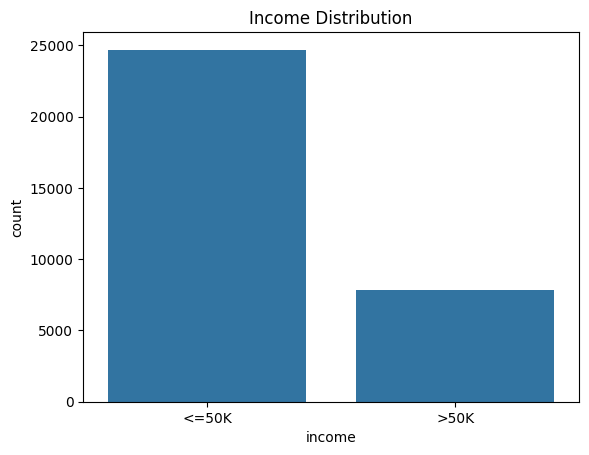

In [17]:
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

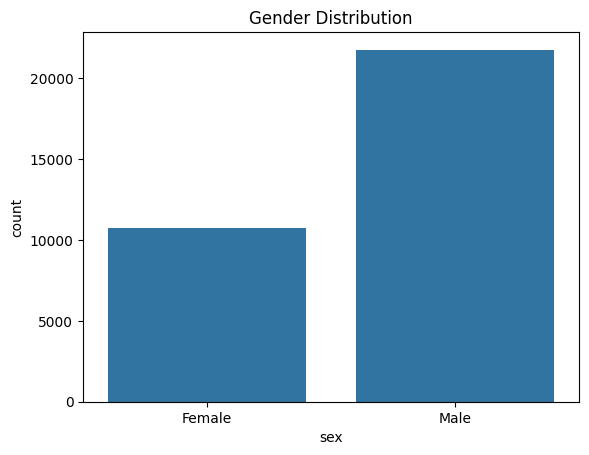

In [18]:
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution")
plt.show()

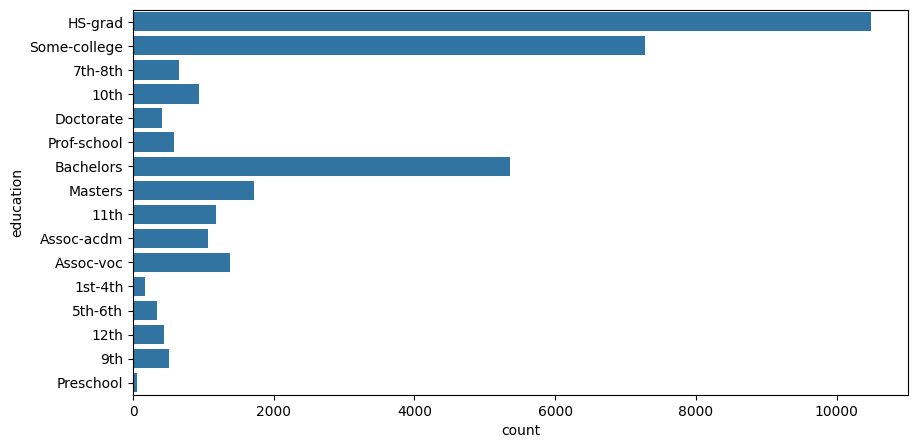

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(y="education", data=df)
plt.show()

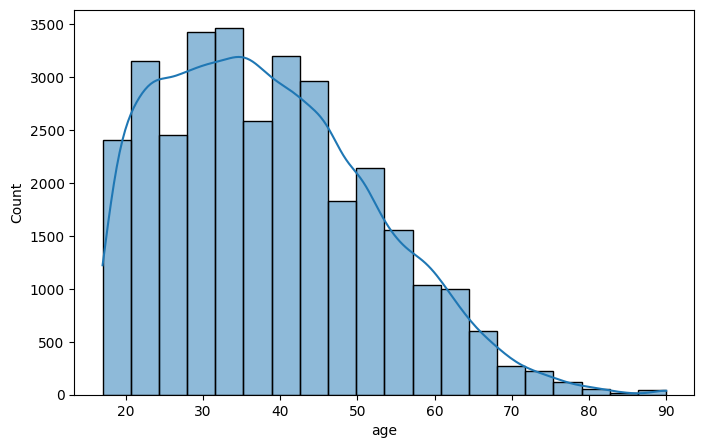

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.show()

In [22]:
X = df.drop("income", axis=1)

y = df["income"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
#Cat Boost

In [25]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [26]:
from catboost import CatBoostClassifier

In [27]:
cat_features = X.select_dtypes(include='object').columns

cat_features

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')

In [28]:
cat_index = [X.columns.get_loc(col) for col in cat_features]

In [29]:
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_index
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, verbose=0)

In [30]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8716963736939152


In [31]:
#ADA Boost

In [42]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

label_encoders = {} # Dictionary to store label encoders for each column

for col in df2.select_dtypes(include='object').columns:
    le = LabelEncoder() # Create a new LabelEncoder for each column
    df2[col] = le.fit_transform(df2[col])
    label_encoders[col] = le # Store the fitted encoder

In [33]:
X = df2.drop("income",axis=1)

y = df2["income"]

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1,
    random_state=42
)

model.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=42)

In [36]:
y_pred=model.predict(X_test)


In [37]:
from sklearn.metrics import accuracy_score

print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.8581745543945912


In [38]:
#Cat Boost Example

In [43]:
new_person = pd.DataFrame({
    'age': [35],
    'workclass': ['Private'],
    'fnlwgt': [180000],
    'education': ['Bachelors'],
    'education.num': [13],
    'marital.status': ['Married-civ-spouse'],
    'occupation': ['Prof-specialty'],
    'relationship': ['Husband'],
    'race': ['White'],
    'sex': ['Male'],
    'capital.gain': [5000],
    'capital.loss': [0],
    'hours.per.week': [45],
    'native.country': ['United-States']
})

# Create a copy to transform
new_person_transformed = new_person.copy()

# Apply the stored LabelEncoders to the categorical columns of new_person
for col in new_person_transformed.select_dtypes(include='object').columns:
    if col in label_encoders:
        new_person_transformed[col] = label_encoders[col].transform(new_person_transformed[col])
    else:
        # This case should ideally not be reached if all categorical columns are handled
        pass

prediction = model.predict(new_person_transformed)

print("Prediction:", prediction)

if prediction[0] == '>50K':
    print("Income is greater than $50K")
else:
    print("Income is less than or equal to $50K")

Prediction: [1]
Income is less than or equal to $50K
